In [288]:
import pickle
import matplotlib.cm as cm
import numpy as np

import plotly_express as px
import plotly.graph_objs as go
import ipywidgets as widgets

#import chart_studio.plotly as py
#from plotly.offline import plot

from plotly.graph_objs import *
from plotly.subplots import make_subplots

In [289]:
with open('bistability_exc_inh_LChigh.pickle','rb') as f:
    load_array= pickle.load(f)
ext_exc_LChigh = load_array[0]
ext_inh_LChigh = load_array[1]
    
with open('bistability_exc_inh.pickle','rb') as f:
    load_array= pickle.load(f)
ext_exc = load_array[0]
ext_inh = load_array[1]
    
with open('control_init.pickle','rb') as f:
    load_array = pickle.load(f)
    
bestControl_init = load_array[0]
costnode_init = load_array[1]
weights_init = load_array[2]

with open('control_0.pickle','rb') as f:
    load_array = pickle.load(f)
    
bestControl_0 = load_array[0]
costnode_0 = load_array[1]
weights_0 = load_array[2]

In [122]:
#with open('bistability_exc_inh.pickle','wb') as f:
#    pickle.dump([ext_exc, ext_inh], f)

In [290]:
not_checked = []
exc_ = []
inh_ = []

for i in range(len(ext_exc)):
    if type(bestControl_0[i]) is type(None):
        print(i, " not checked yet")
        not_checked.append(i)
        continue
    elif np.amax(np.abs(bestControl_0[i][0,0,:])) < 1e-8 and np.amax(np.abs(bestControl_0[i][0,1,:])) > 1e-8:
        inh_.append(i)
        print(i, " only inhibitory current")
    elif np.amax(np.abs(bestControl_0[i][0,1,:])) < 1e-8 and np.amax(np.abs(bestControl_0[i][0,0,:])) > 1e-8:
        exc_.append(i)
        print(i, " only excitatory current")
    elif np.amax(np.abs(bestControl_0[i][0,0,:])) < 1e-8 and np.amax(np.abs(bestControl_0[i][0,1,:])) < 1e-8:
        print(i, "no control input")
    elif np.amax(np.abs(bestControl_0[i][0,0,:])) > 1e-8 and np.amax(np.abs(bestControl_0[i][0,1,:])) > 1e-8:
        print(i, " control input in both nodes")
    else:
        print(i, " no category")

0  only excitatory current
1  not checked yet
2  not checked yet
3  not checked yet
4  not checked yet
5  only excitatory current
6  not checked yet
7  not checked yet
8  not checked yet
9  not checked yet
10  only excitatory current
11  only excitatory current
12  only excitatory current
13  only excitatory current
14  only excitatory current
15  only excitatory current
16  only excitatory current
17  only inhibitory current
18  only inhibitory current
19  only inhibitory current
20  only inhibitory current
21  not checked yet
22  not checked yet
23  not checked yet
24  not checked yet
25  only inhibitory current
26  not checked yet
27  not checked yet
28  not checked yet
29  not checked yet
30  only inhibitory current
31  not checked yet
32  not checked yet
33  not checked yet
34  not checked yet
35  only inhibitory current
36  not checked yet
37  not checked yet
38  not checked yet
39  not checked yet
40  only inhibitory current
41  not checked yet
42  not checked yet
43  not checke

In [314]:
darkgrey = 'rgb(100,100,100)'
midgrey = 'rgb(200,200,200)'
lightgrey='rgb(280,280,280)'

cmap=cm.get_cmap('tab10')

# not investigated yet
exc_0 = []
inh_0 = []
colors = []
sizes = []
lenx_ = []
leny_ = []

boundary_bi_exc = []
boundary_bi_inh = []
boundary_up_exc = []
boundary_up_inh = []

for i in range(len(ext_exc)):
    boundary_bi_exc.append(ext_exc[i])
    boundary_bi_inh.append(ext_inh[i])
    #boundary_up_exc = []
    #boundary_up_inh
    
    if i in not_checked:
        exc_0.append(ext_exc[i])
        inh_0.append(ext_inh[i])
        colors.append(lightgrey)
        sizes.append(6)
        lenx_.append(0)
        leny_.append(0)

    elif i in exc_:
        exc_0.append(ext_exc[i])
        inh_0.append(ext_inh[i])
        colors.append('rgba' + str(cmap(3)))
        sizes.append(12)

        lenx = np.amax(bestControl_0[i][0,0,:])
        if np.abs(np.amin(bestControl_0[i][0,0,:])) > np.abs(lenx):
            lenx = np.amin(bestControl_0[i][0,0,:])
        leny = np.amax(bestControl_0[i][0,1,:])
        if np.abs(np.amin(bestControl_0[i][0,1,:])) > np.abs(leny):
            leny = np.amin(bestControl_0[i][0,1,:])
        lenx_.append(lenx)
        leny_.append(leny)

    elif i in inh_:
        exc_0.append(ext_exc[i])
        inh_0.append(ext_inh[i])
        colors.append('rgba' + str(cmap(0)))
        sizes.append(12)

        lenx = np.amax(bestControl_0[i][0,0,:])
        if np.abs(np.amin(bestControl_0[i][0,0,:])) > np.abs(lenx):
            lenx = np.amin(bestControl_0[i][0,0,:])
        leny = np.amax(bestControl_0[i][0,1,:])
        if np.abs(np.amin(bestControl_0[i][0,1,:])) > np.abs(leny):
            leny = np.amin(bestControl_0[i][0,1,:])
        lenx_.append(lenx)
        leny_.append(leny)
    
data = go.Scatter(
    x=exc_0,
    y=inh_0,
    marker=dict(
        line=dict(width=2,
                  color=midgrey,
            ),
    ),
    mode='markers'
    )

data1 = go.Scatter(
    x=boundary_bi_exc,
    y=boundary_bi_inh,
    mode='lines',
    name='Bistable regime',
    marker_color='rgba' + str(cmap(9)),
    fillcolor='rgba' + str(cmap(9)),
    opacity=0.1,
    fill="toself",
    )

In [316]:
#f = go.FigureWidget()
#f.make_subplots(rows=1, cols=2)
#f.add_trace(data, row=1, col=1)

#from skimage import data
#img = data.astronaut()
#image = px.imshow(img, binary_format="jpeg", binary_compression_level=0)
#image.show()
f = go.FigureWidget([data,data1])

scatter = f.data[0]
scatter.marker.color = colors
scatter.marker.size = sizes

layout = Layout(
    width = 1000,
    height = 1000,
    margin=dict(l=10, r=600, t=40, b=10, pad=0),
    paper_bgcolor=midgrey,
    plot_bgcolor=lightgrey,
    hovermode='closest'
)

info_text = Annotation(
        x=2.37,
        y=0.8,
        text=("Task: low to high state switching in bistable regime (no adaptation)<br>"
              "Cost measure: sparsity, precision after 80 ms<br>"
              "Allowed control: current control in excitatory and inhibitory node<br>"
              "Initial guess: excitatory current<br>"),
        xref="paper",
        yref="paper",
        showarrow=False,
        font=dict(
            size=14,
            color=darkgrey
            ),
        align="left",
        bordercolor=darkgrey,
        borderwidth=1,
        borderpad=4,
        bgcolor=lightgrey,
        opacity=0.8,
        )
f.add_annotation(info_text)

f.update_layout(layout)

f.update_xaxes(
    range=[1.5,4.5],
    constrain="domain",
    tick0=1.5,
    dtick=0.5,
    gridcolor=midgrey,
)
f.update_yaxes(
    scaleanchor = "x",
    scaleratio = 1,
    tick0=1.5,
    dtick=0.5,
    gridcolor=midgrey,
)

def show_arrow_and_traces(trace, points, state):
    f.update_annotations(visible=True)
    ind = points.point_inds
    
    f.layout.annotations = f.layout.annotations[:1]
    
    xarrow = Annotation(
        x=exc_0[ind[-1]]+lenx_[ind[-1]],
        y=inh_0[ind[-1]],
        xref="x",
        yref="y",
        showarrow=True,
        arrowhead=2,
        arrowsize=1,
        arrowwidth=2,
        arrowcolor=darkgrey,
        axref='x',
        ayref='y',
        ax=exc_0[ind[-1]],
        ay=inh_0[ind[-1]],
        )
    yarrow = Annotation(
        x=exc_0[ind[-1]],
        y=inh_0[ind[-1]]+leny_[ind[-1]],
        xref="x",
        yref="y",
        showarrow=True,
        arrowhead=2,
        arrowsize=1,
        arrowwidth=2,
        arrowcolor=darkgrey,
        axref='x',
        ayref='y',
        ax=exc_0[ind[-1]],
        ay=inh_0[ind[-1]],
        )
    f.add_annotation(xarrow)
    f.add_annotation(yarrow)
    f.update_annotations(visible=True)
    
    if ind[-1] in exc_ or ind[-1] in inh_:
        img_source = './plots_/init_0_' + str(ind[-1]) + '.png'
    else:
        f.update_layout_image(visible=False)
        return
    
    img_dict = dict(
        source=img_source,
        xref="paper",
        yref="paper",
        #sizing="contain",
        x=1.05,
        y=0.69,
        sizex=1.5,
        sizey=1.5,
        opacity=1.,
        xanchor="left",
        yanchor="top",
        )
    
    f.add_layout_image(img_dict)

for f_ in f.data:
    f_.on_click(show_arrow_and_traces)

display(f)

FigureWidget({
    'data': [{'marker': {'color': [rgba(0.8392156862745098, 0.15294117647058825,
              …

In [296]:
# plot and save for all data points
from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
import os

path = os.path.join(os.getcwd(), "plots_")

aln = ALNModel()

aln.params.sigma_ou = 0.
aln.params.mue_ou = np.array( [0.] )
aln.params.mui_ou = np.array( [0.] )
aln.params.mue_ext_mean = 0.
aln.params.mui_ext_mean = 0.

aln.params.sigmae_ext = 0.5
aln.params.sigmai_ext = 0.5

# NO ADAPTATION
aln.params.a = 0.
aln.params.b = 0.

dur = 100
dur_pre = 10
dur_post = 10

trans_time = 0.8

#initVars = [None] * len(ext_exc)
#target = [None] * len(ext_exc)

state_vars = aln.state_vars

-------  17 2.8000000000000003 2.15


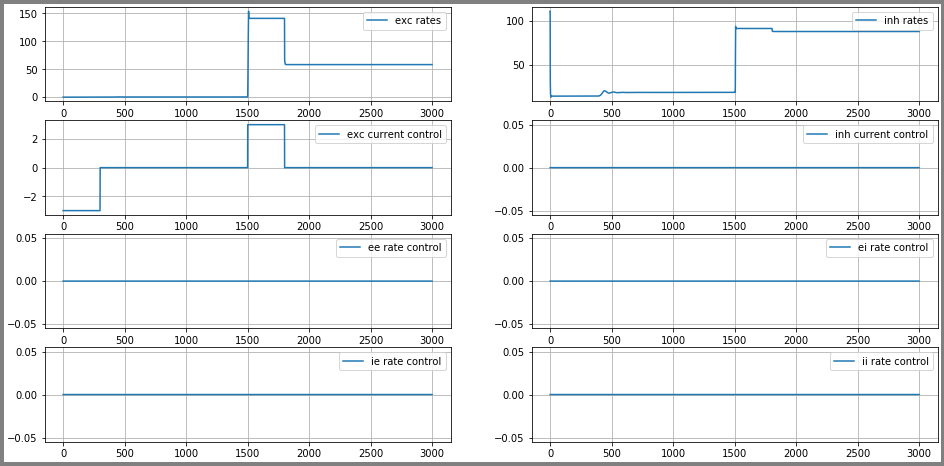

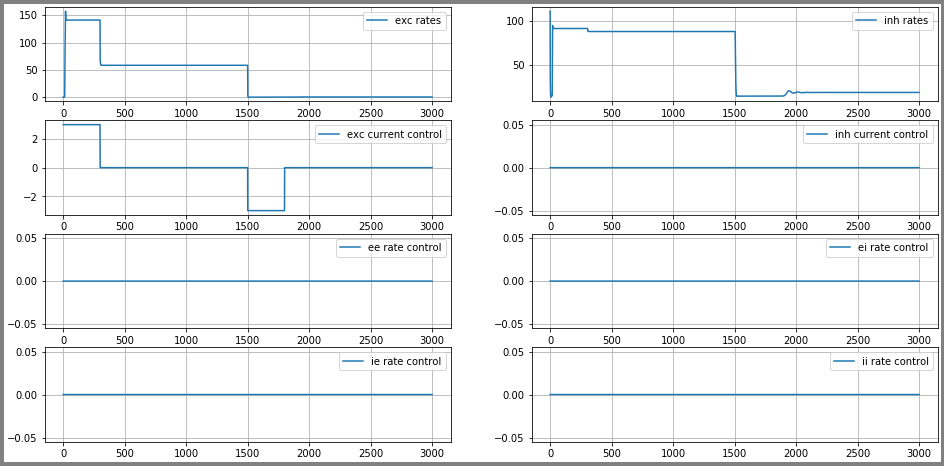

-------  18 2.75 2.1


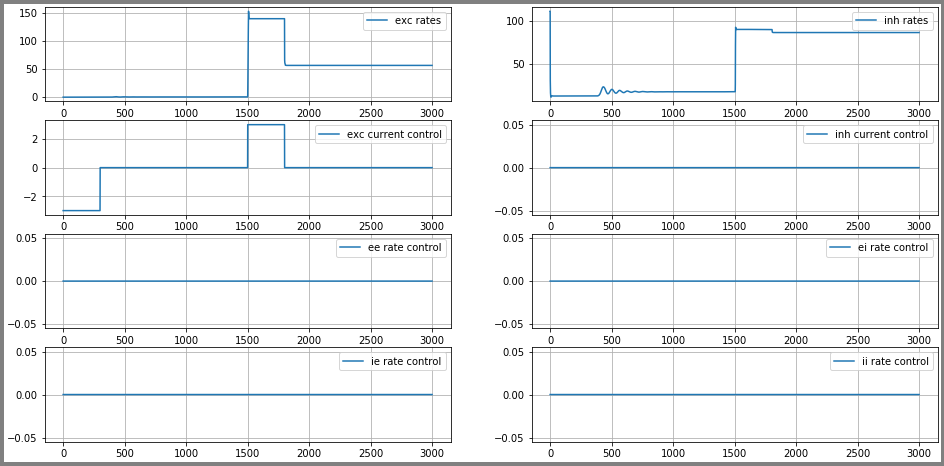

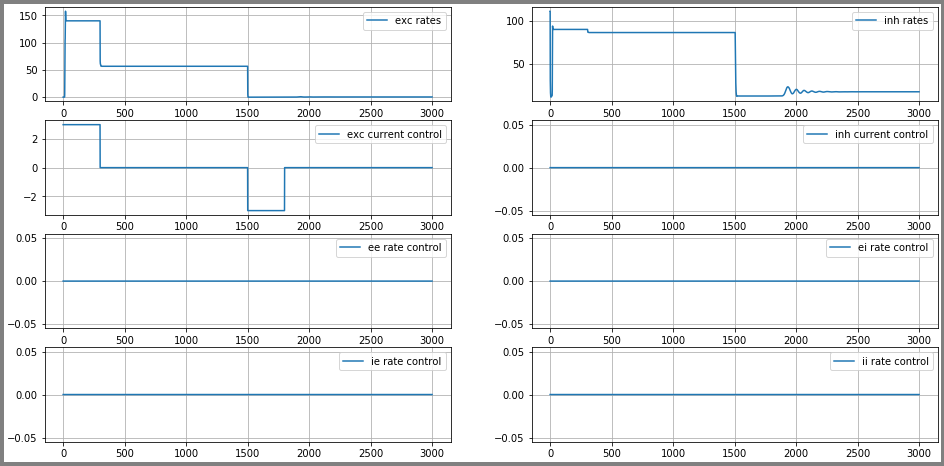

-------  19 2.7 2.1


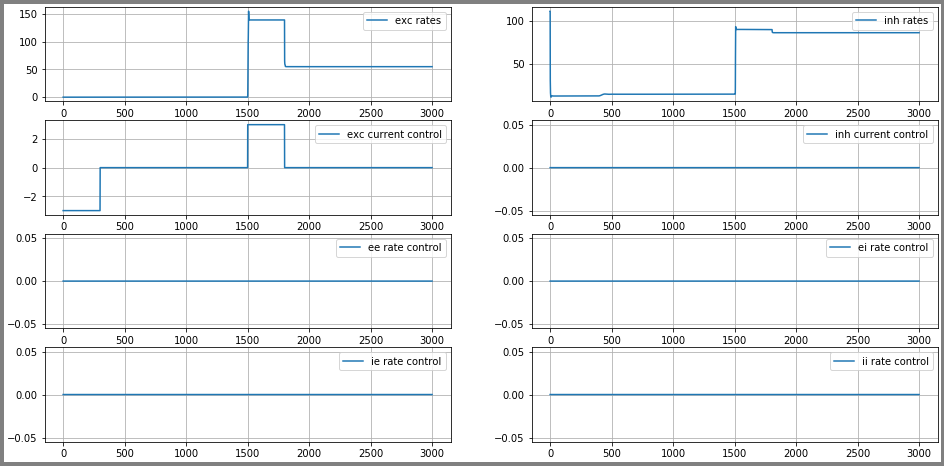

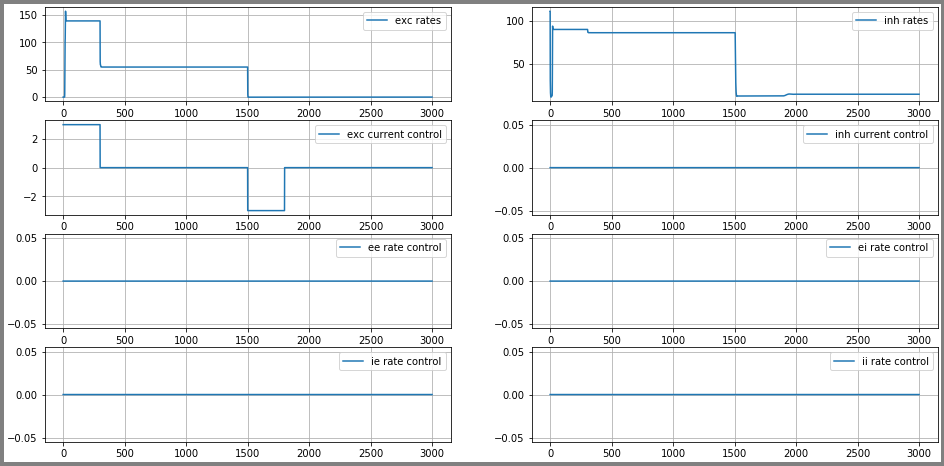

-------  20 2.6500000000000004 2.05


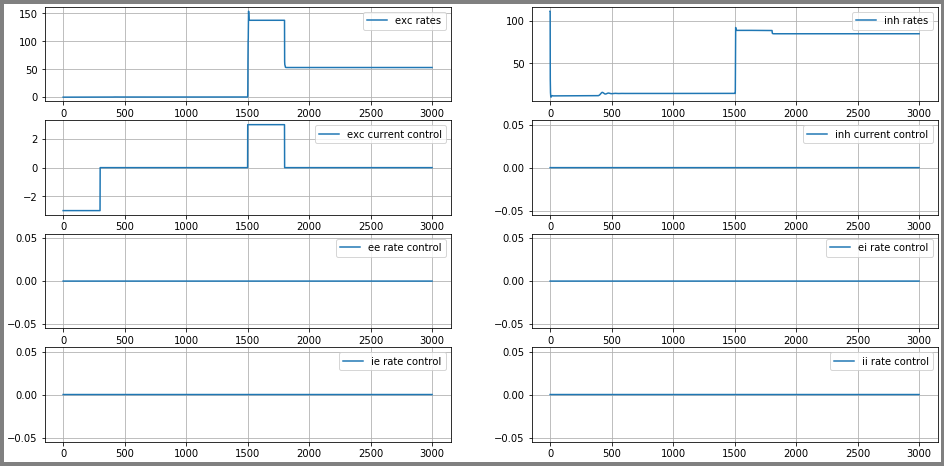

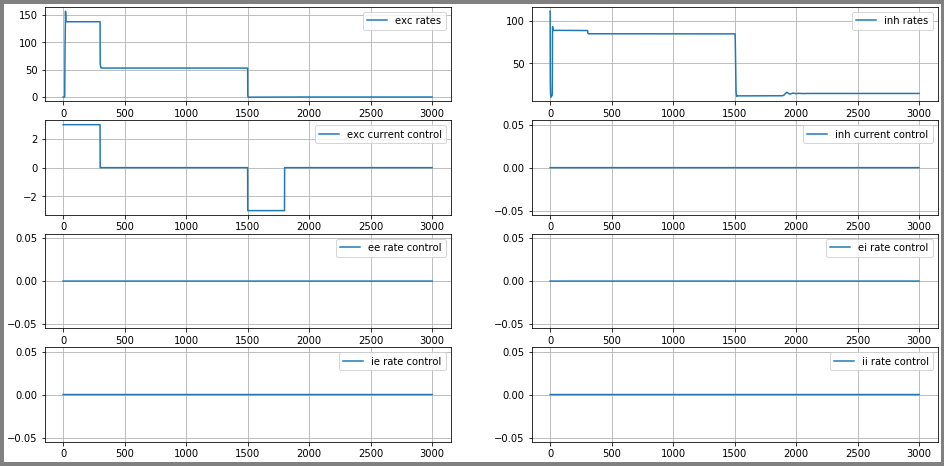

-------  25 2.4 1.9500000000000002


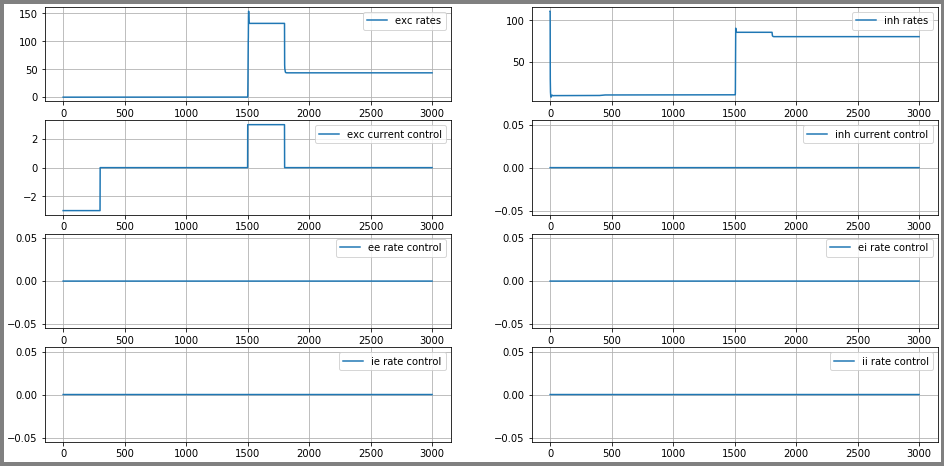

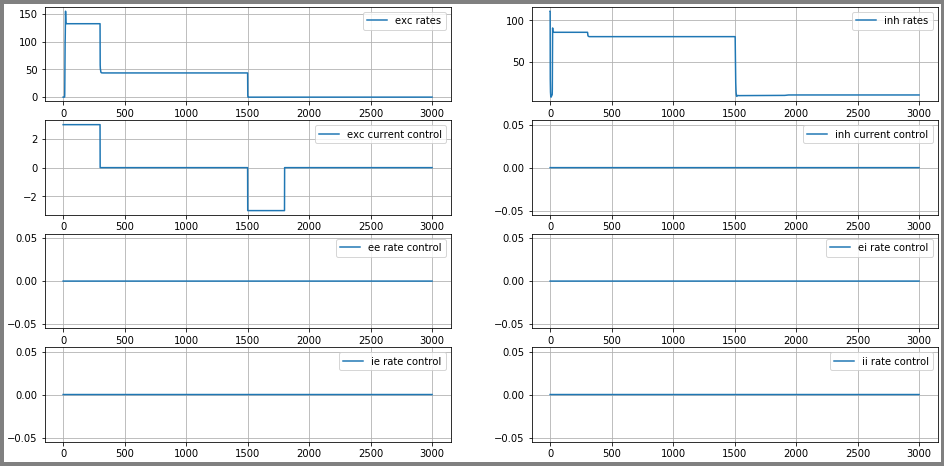

-------  30 2.15 1.7999999999999998


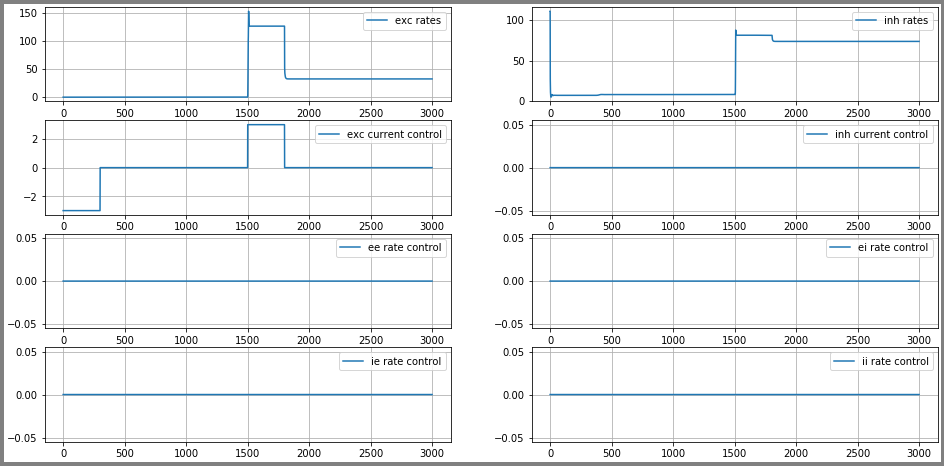

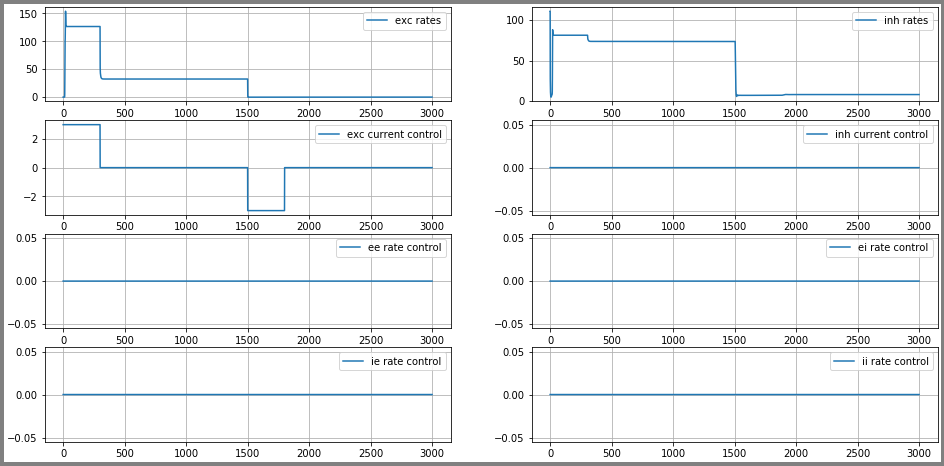

-------  35 2.0 1.7999999999999998


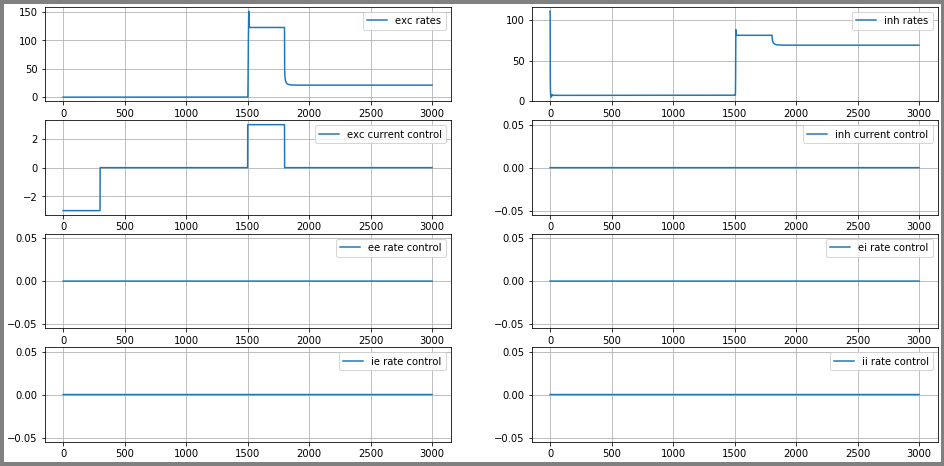

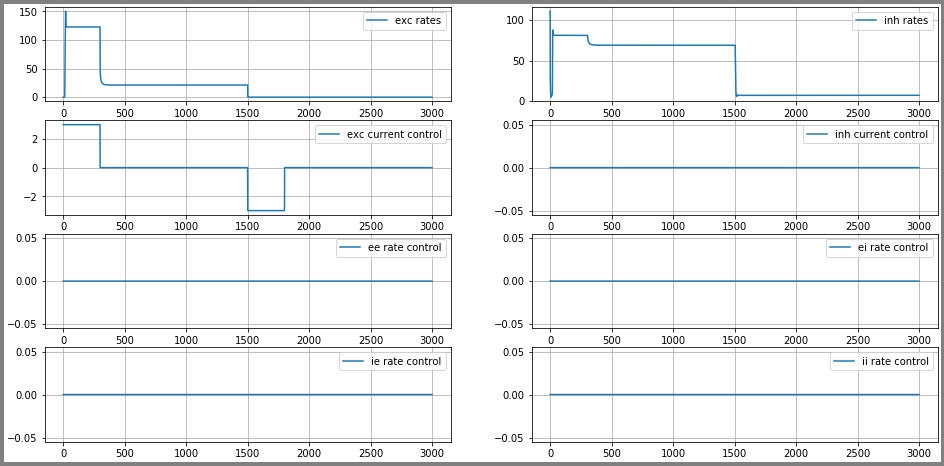

-------  40 2.05 2.05


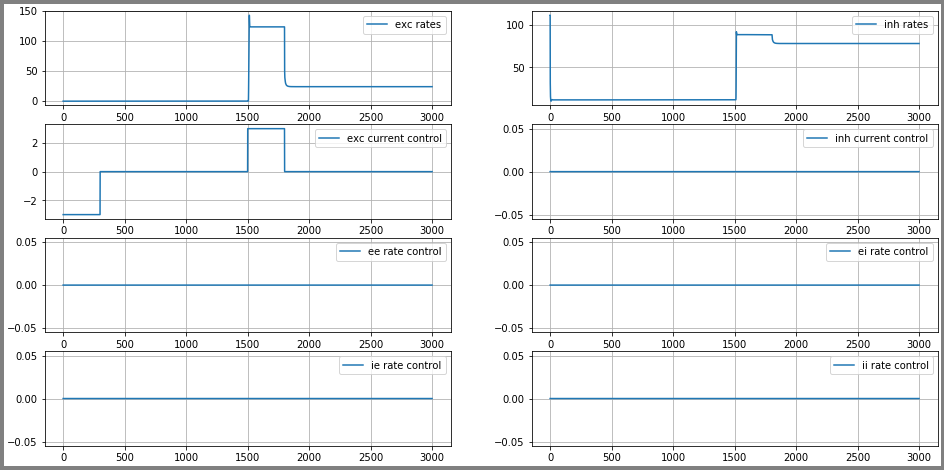

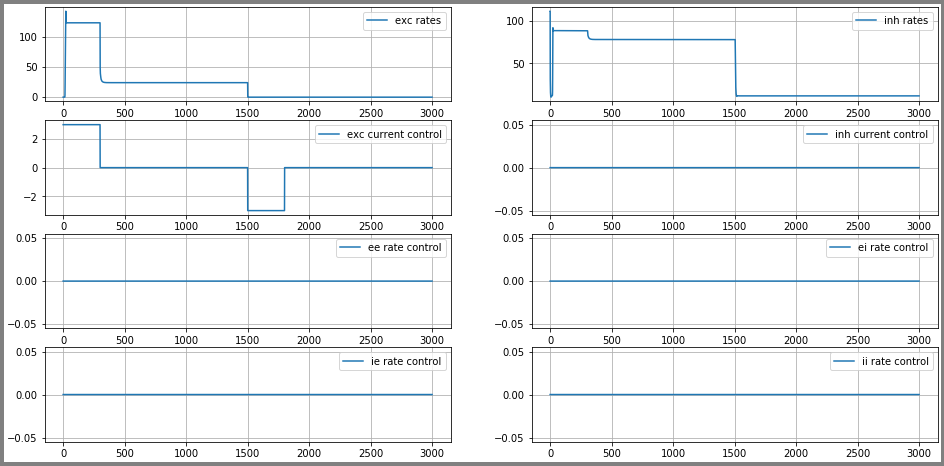

-------  45 2.05 2.3000000000000003


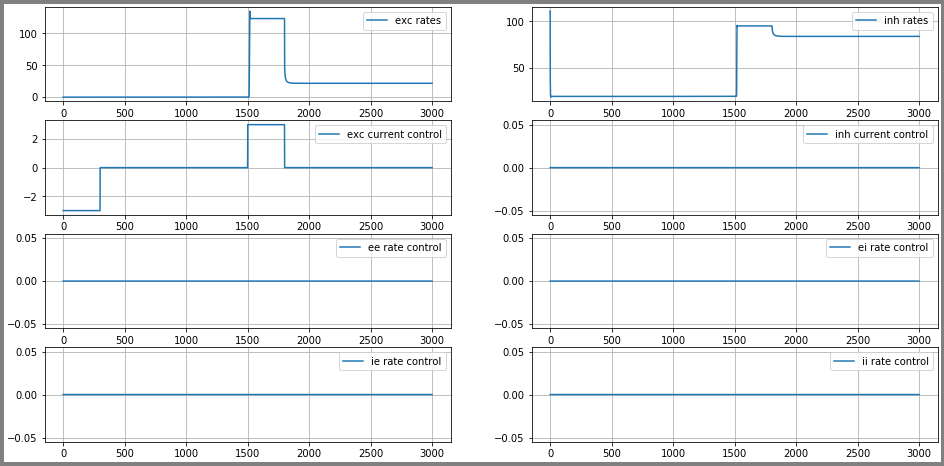

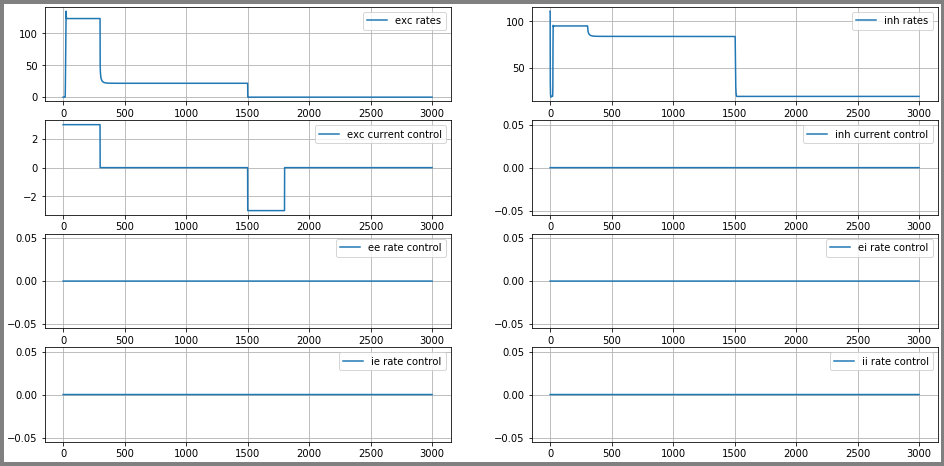

-------  46 2.05 2.3499999999999996


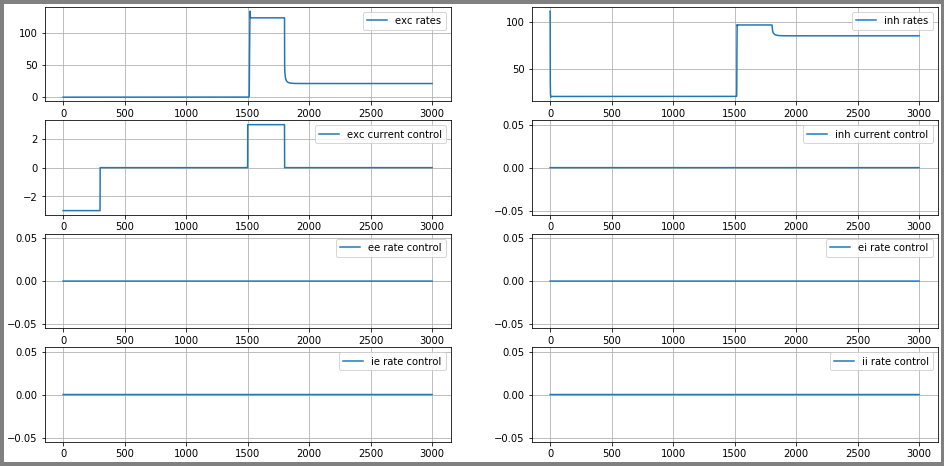

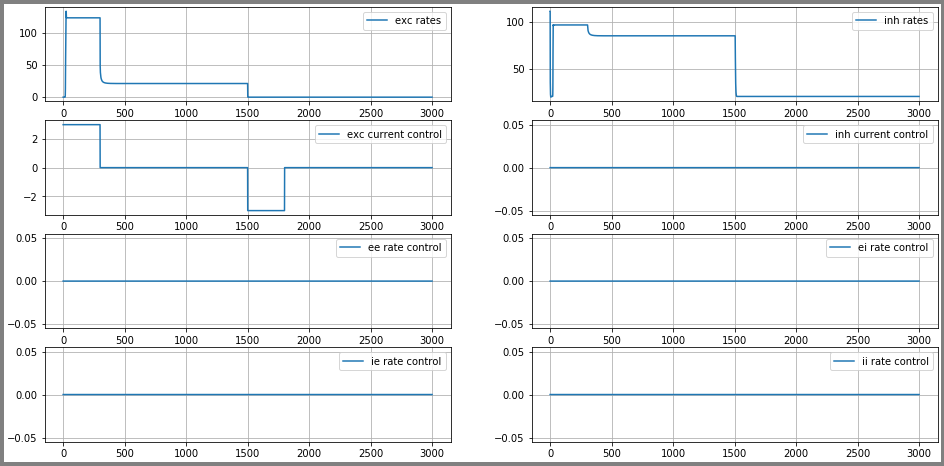

-------  47 2.05 2.4


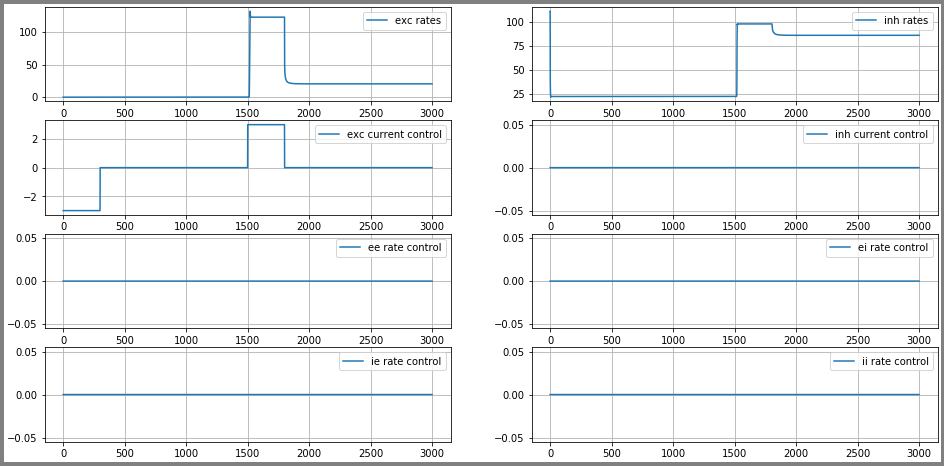

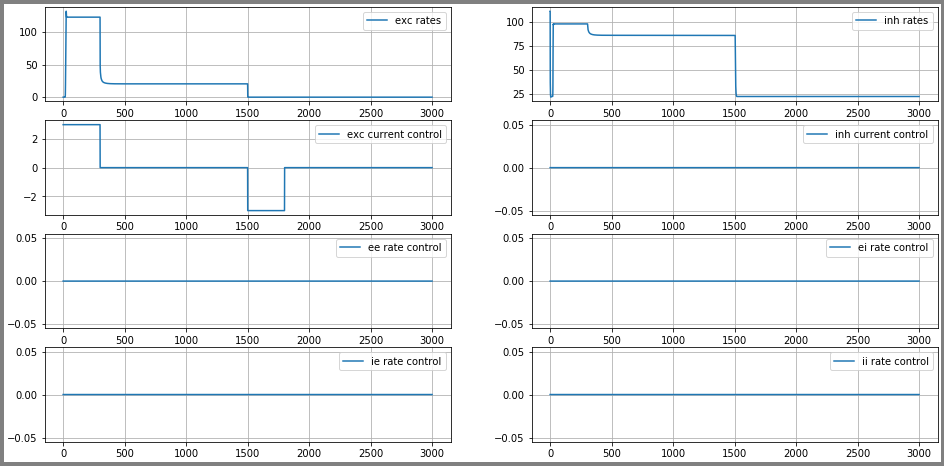

In [279]:
def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.1):
            control_[:,:1,i_time] = - maxI_
        elif ( float(i_time/control_.shape[2]) > 0.5 and float(i_time/control_.shape[2]) < 0.6 ):
            control_[:,:1,i_time] = maxI_
    return control_

for i in inh_:
    print("------- ", i, ext_exc[i], ext_inh[i])
    aln.params.ext_exc_current = ext_exc[i]
    aln.params.ext_inh_current = ext_inh[i]
    
    aln.params.duration = 3000.
    
    control0 = aln.getZeroControl()
    control0 = step_control(maxI_ = 3.)

    plotFunc.plot_traces(aln, control0)
    
    steady_rates = np.zeros((2, 2))
    steady_rates[0,0] = aln.rates_exc[0,-1] # high state exc
    steady_rates[0,1] = aln.rates_inh[0,-1] # high state inh
    
    control0 = step_control(maxI_ = -3.)
    plotFunc.plot_traces(aln, control0, path_=path, filename_="bistability")

    low_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            low_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            low_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = low_state_vars
    
    aln.params.duration = dur
    target[i] = aln.getZeroTarget()
    target[i][:,0,:] = steady_rates[0,0]
    target[i][:,1,:] = steady_rates[0,1]
    

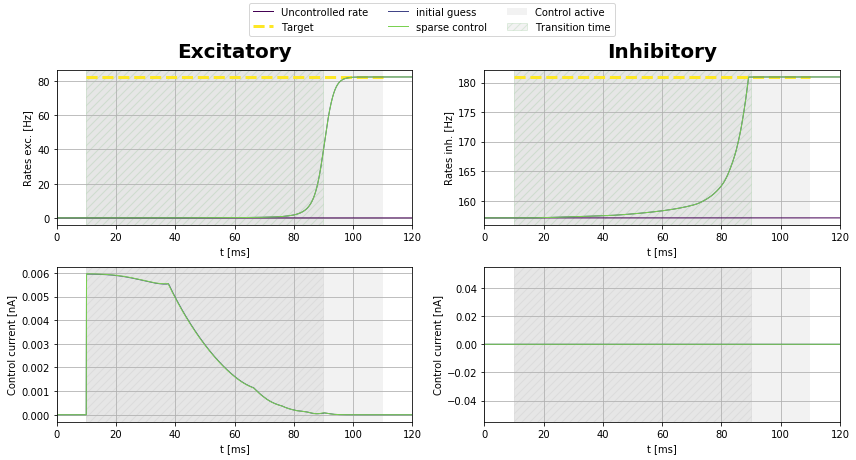

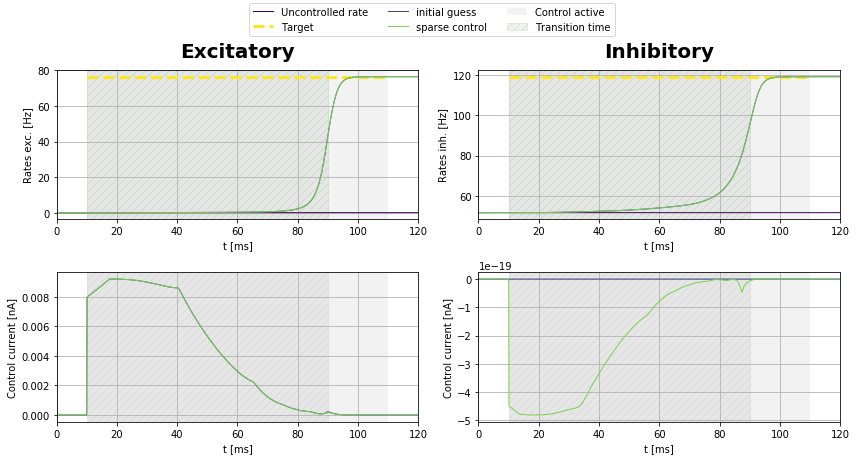

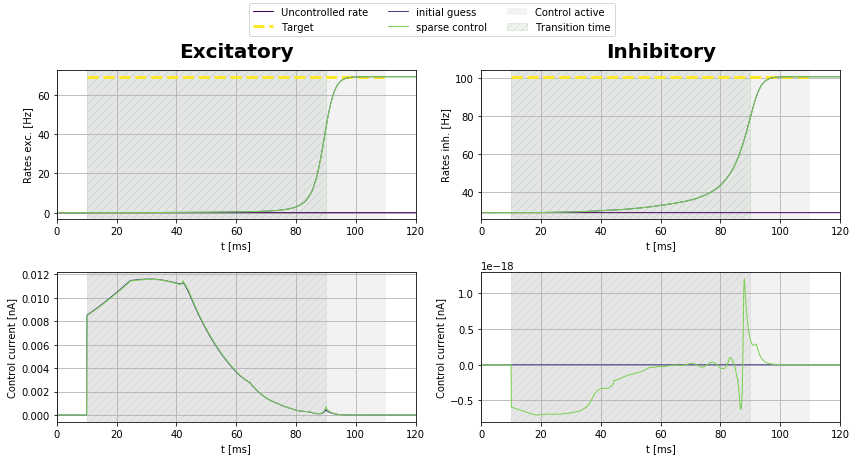

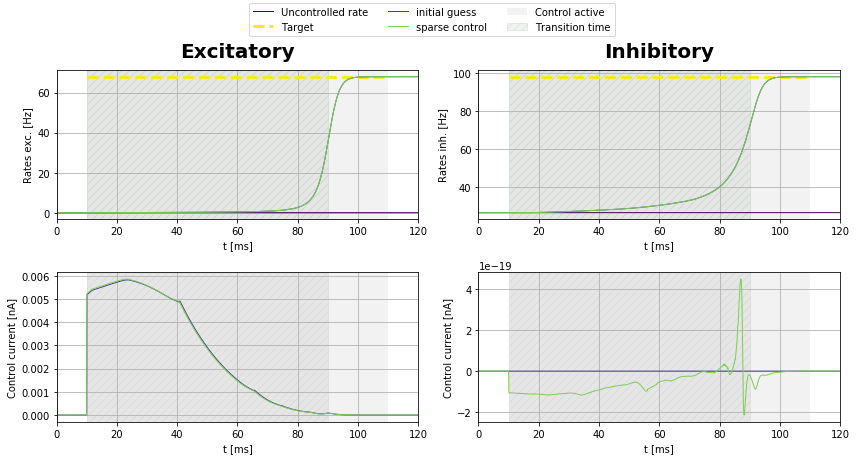

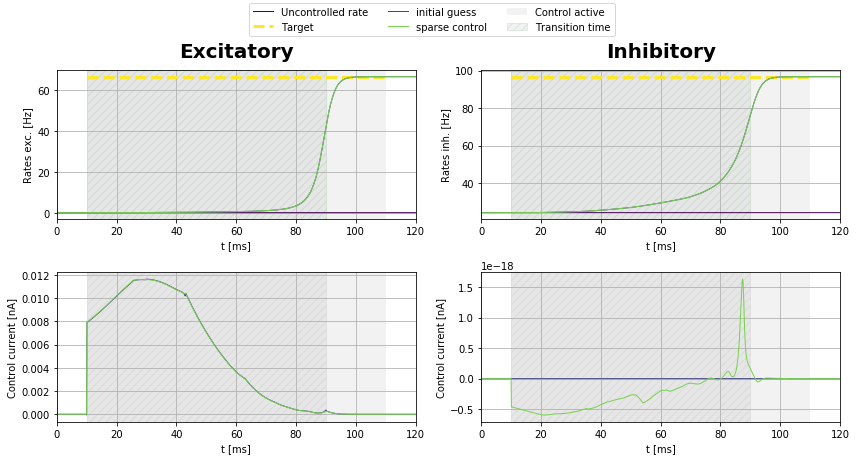

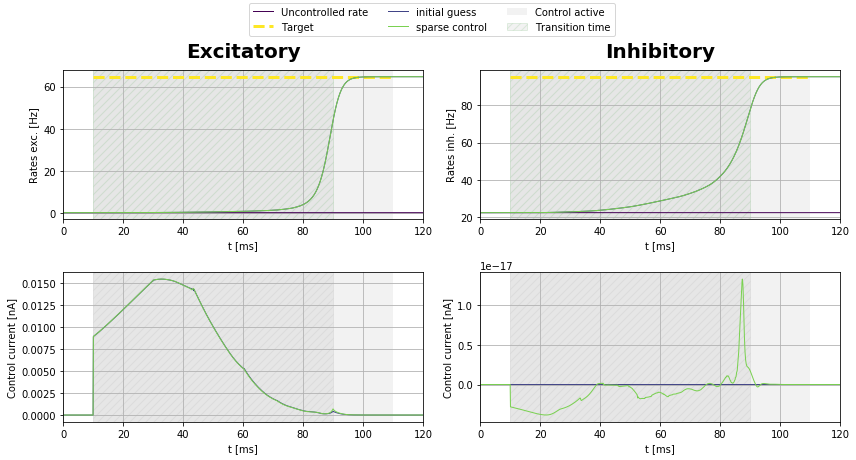

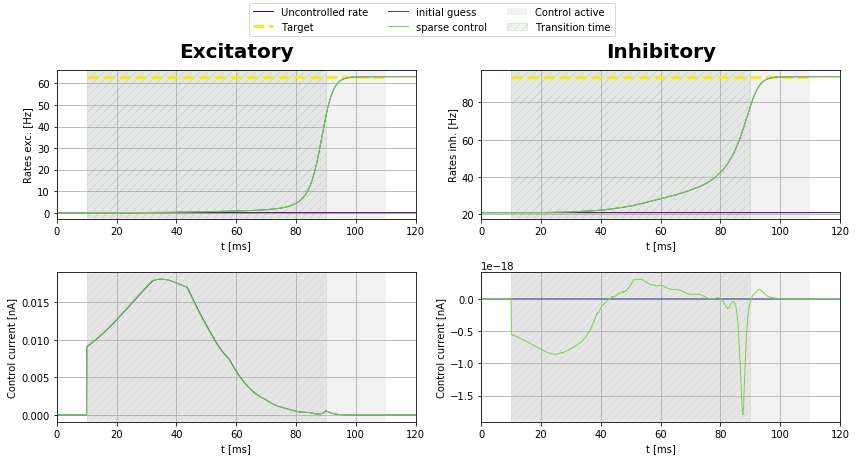

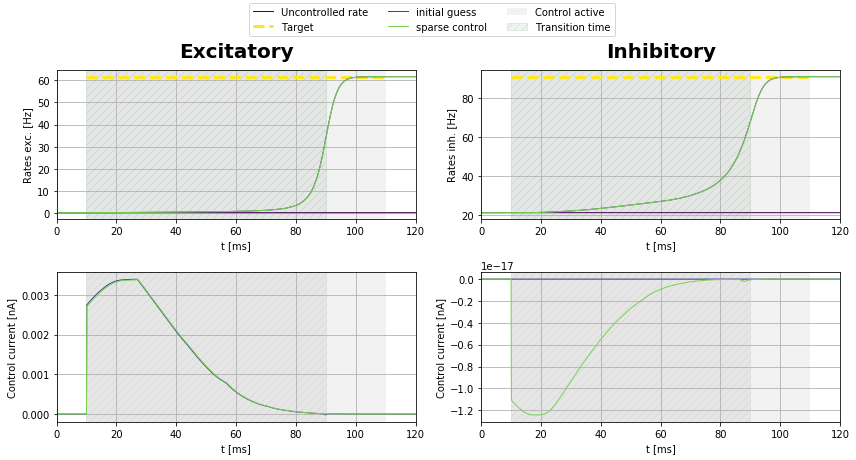

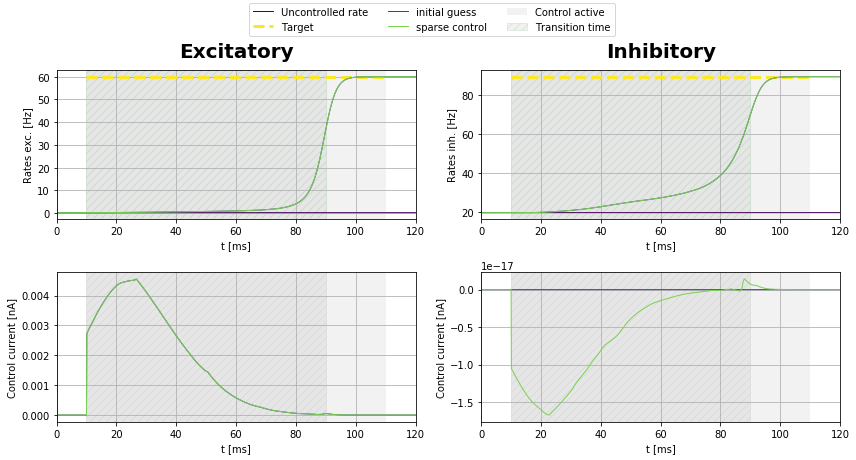

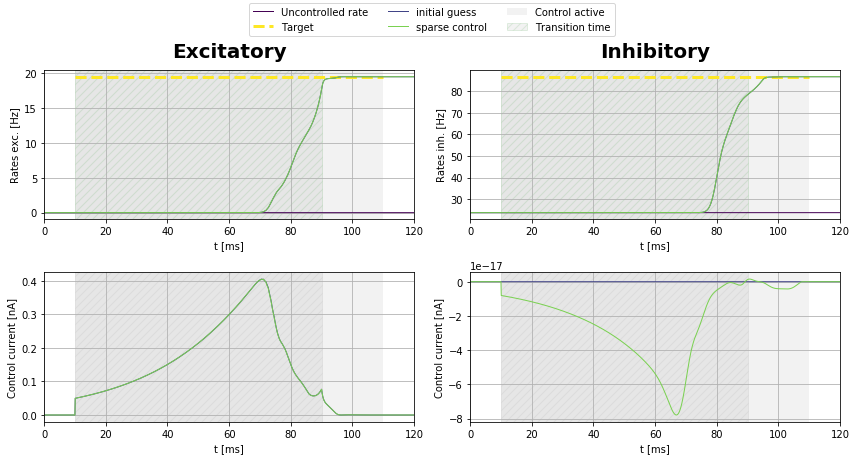

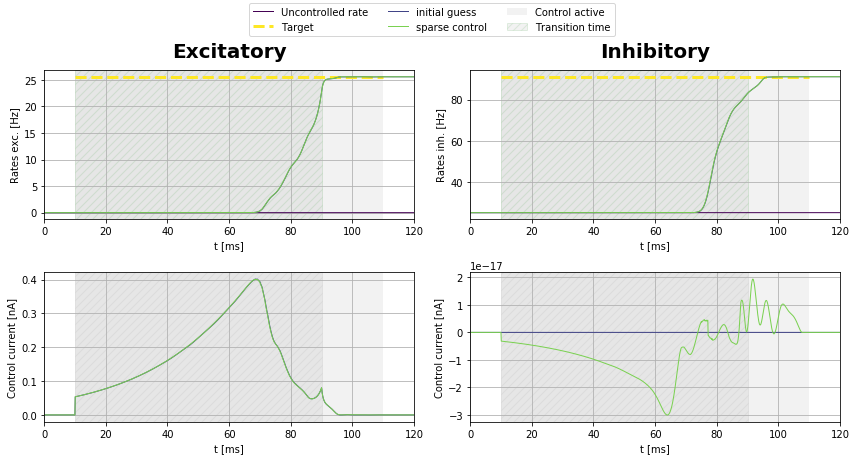

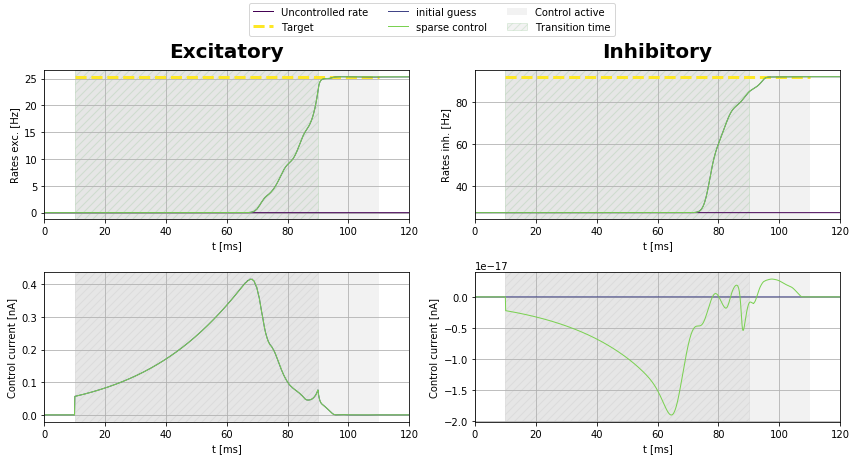

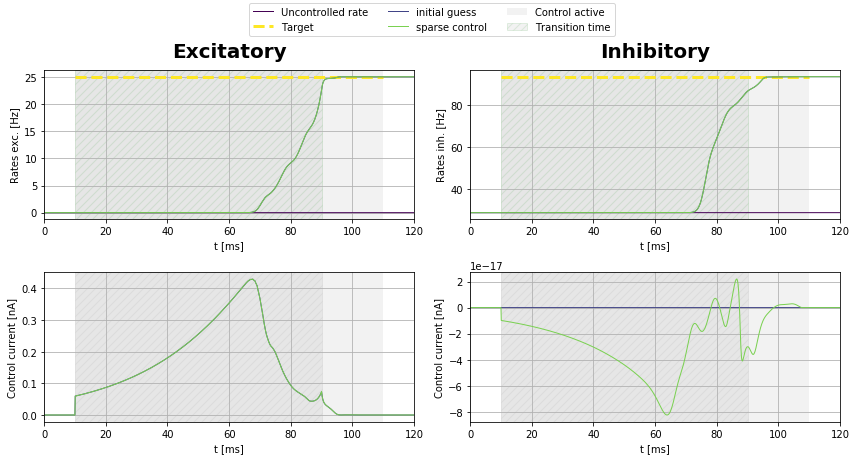

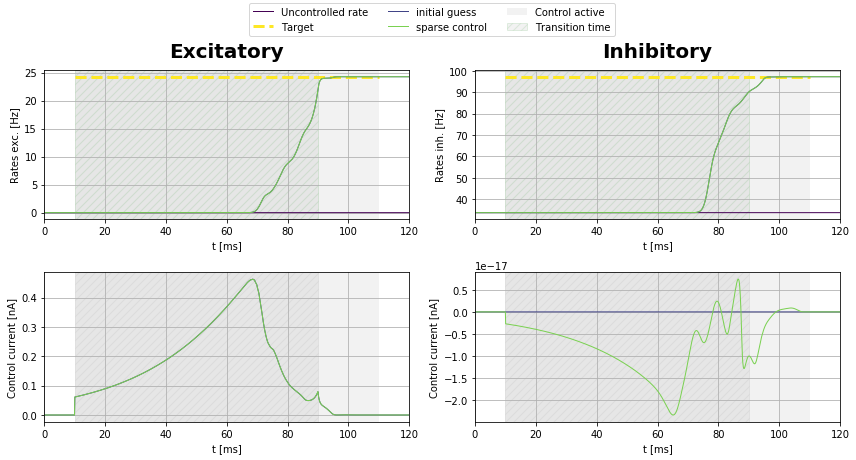

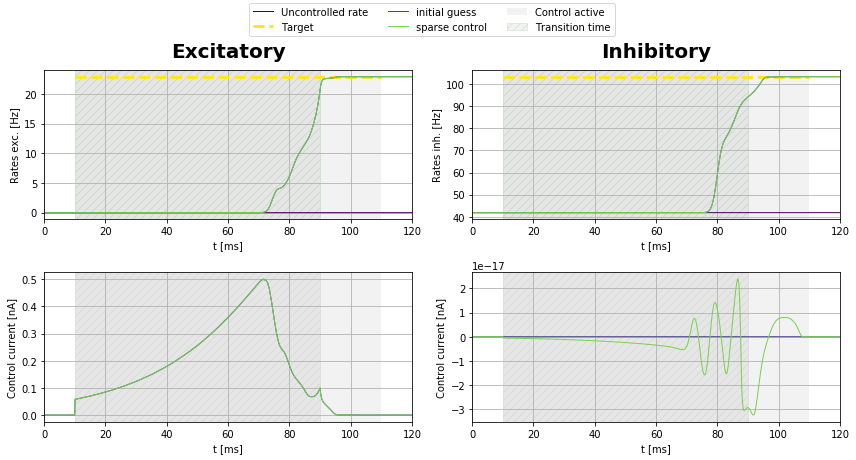

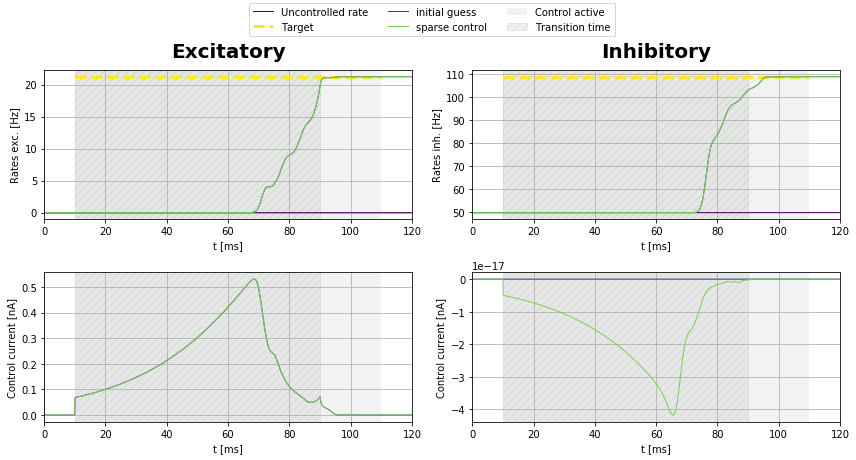

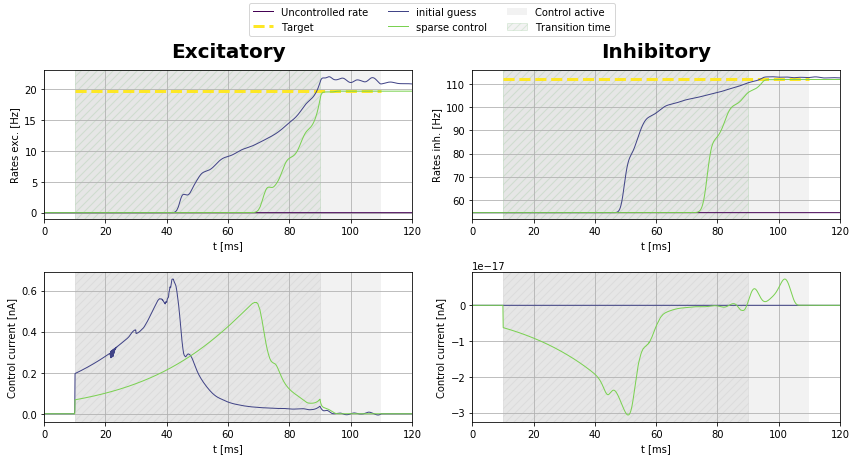

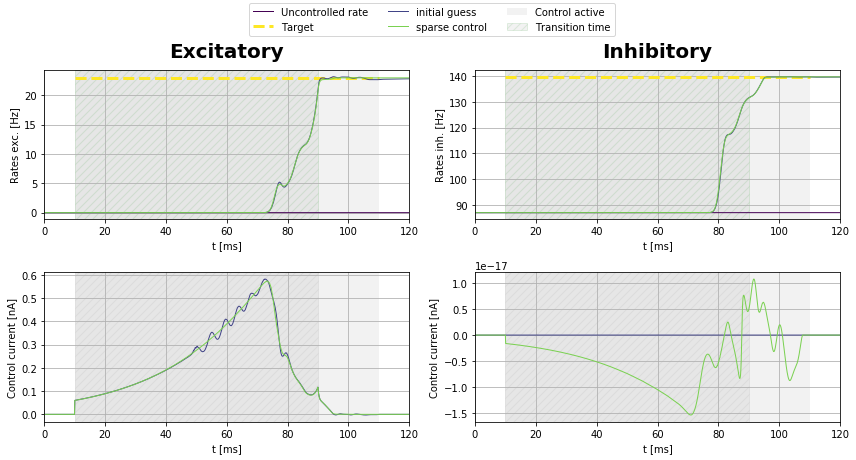

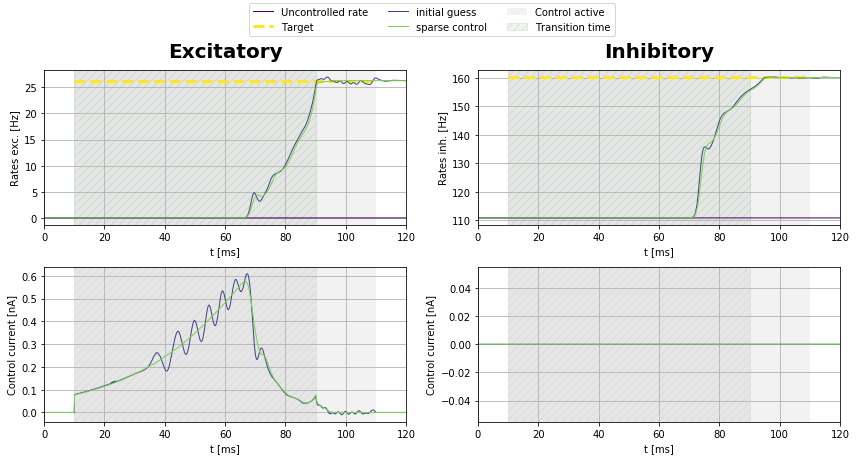

In [297]:
for i in exc_: 
    file_ = "init_0_" + str(i)
    aln.params.ext_exc_current = ext_exc[i]
    aln.params.ext_inh_current = ext_inh[i]
    
    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],
        [costnode_init[i], costnode_0[i]], [[1.,0.,1.], [1.,0.,1.]], dur,
        dur_pre, dur_post, initVars[i], target[i], path, filename_ = file_, transition_time_ = trans_time,
        labels_ = ["initial guess", "sparse control"], print_cost_=False)

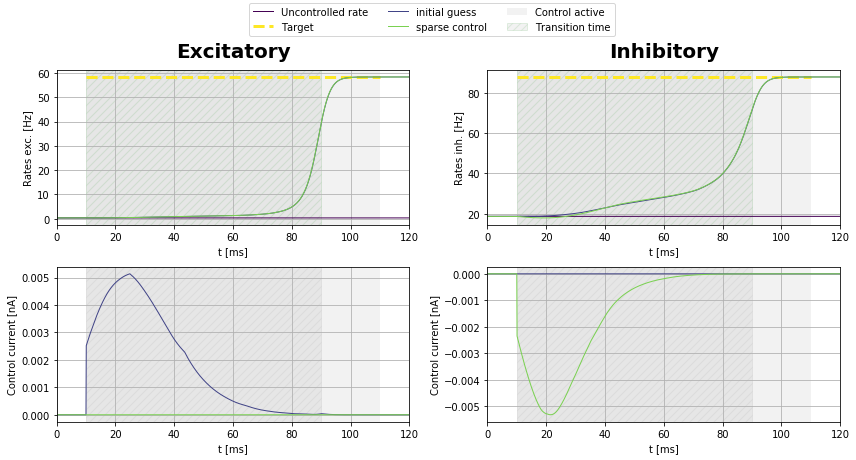

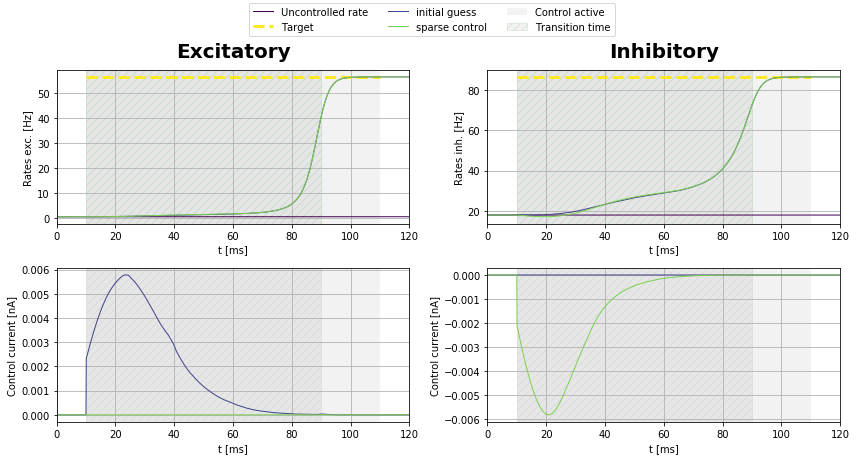

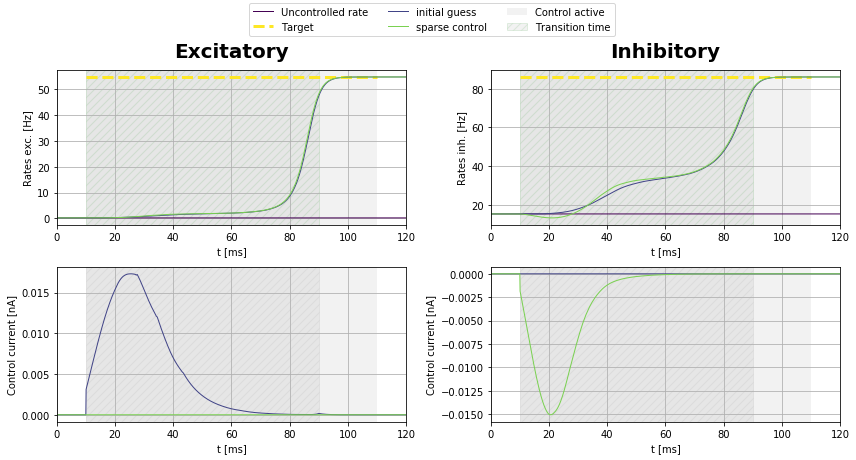

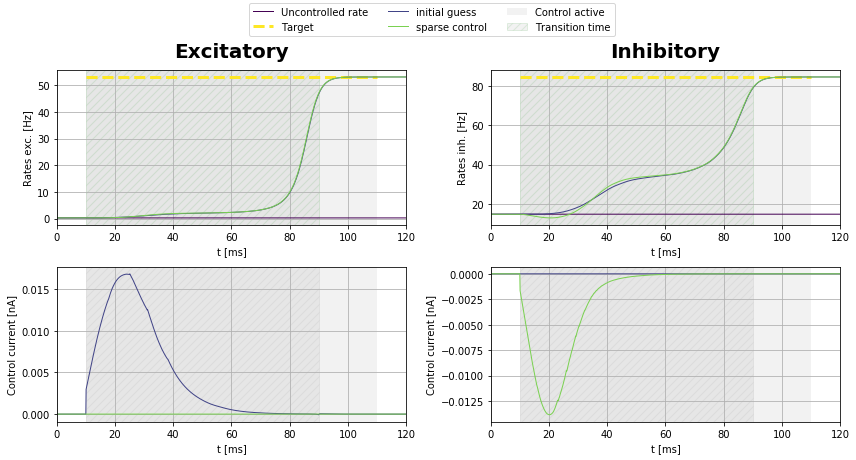

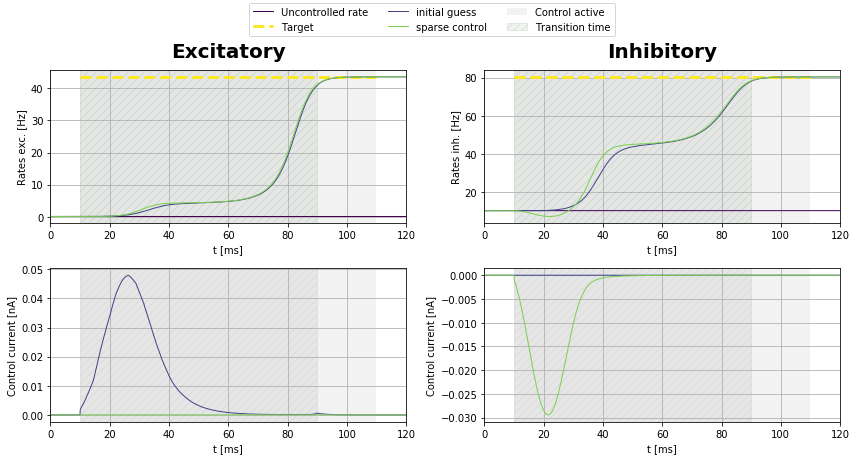

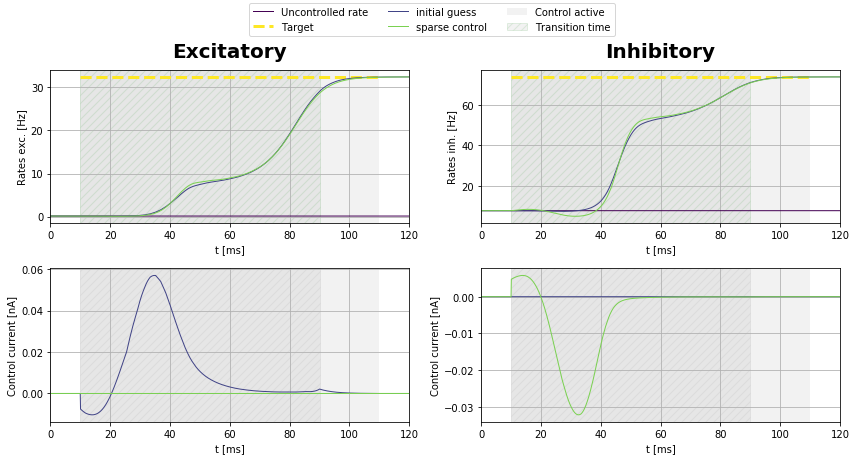

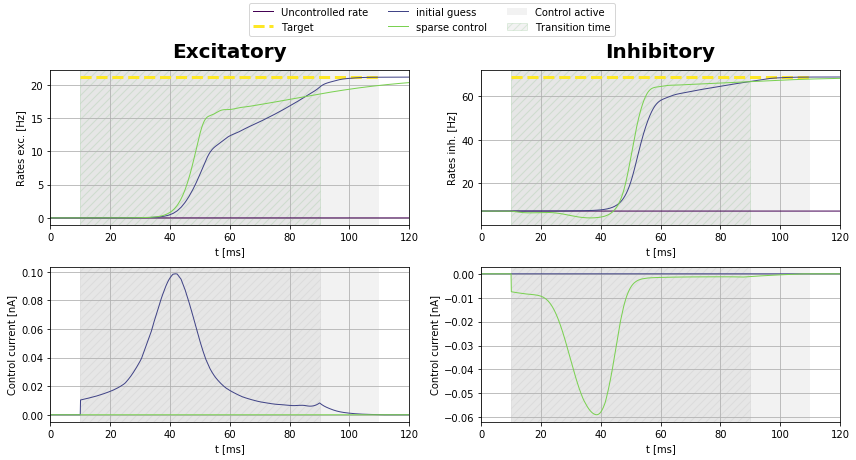

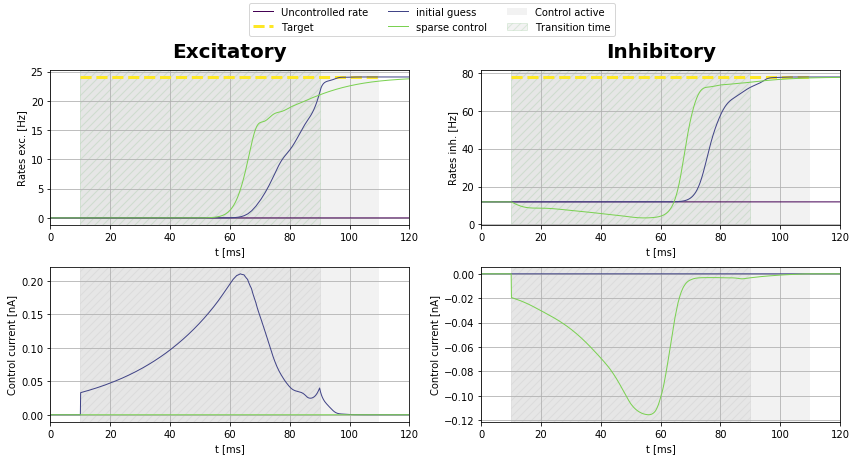

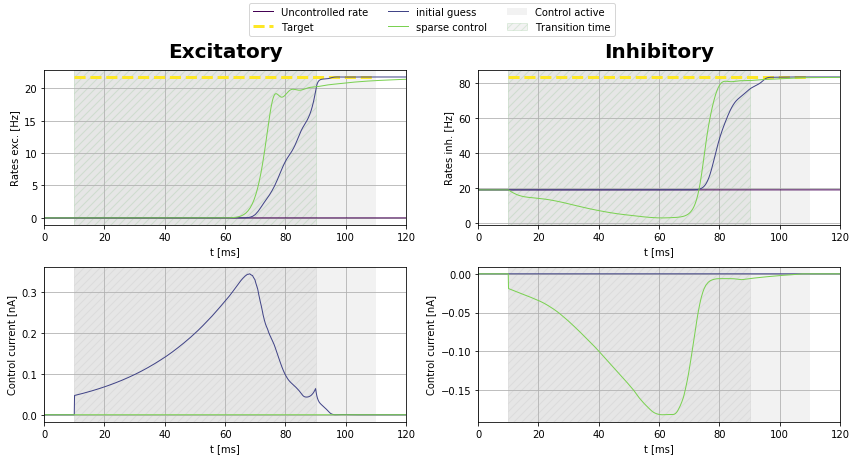

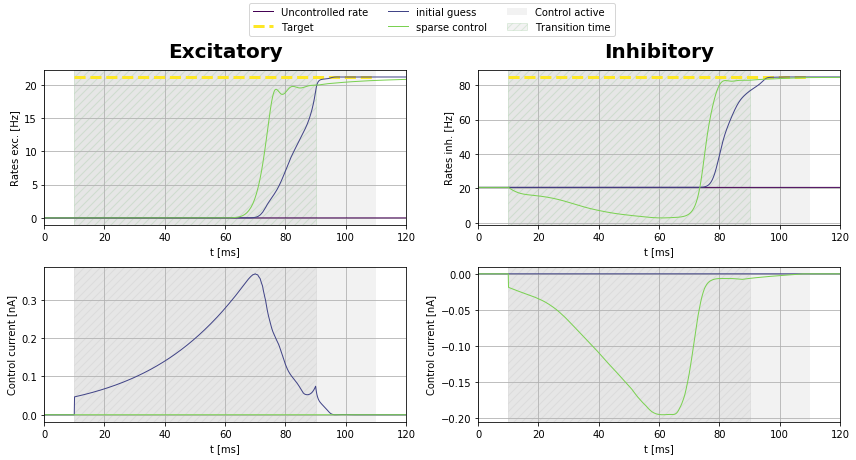

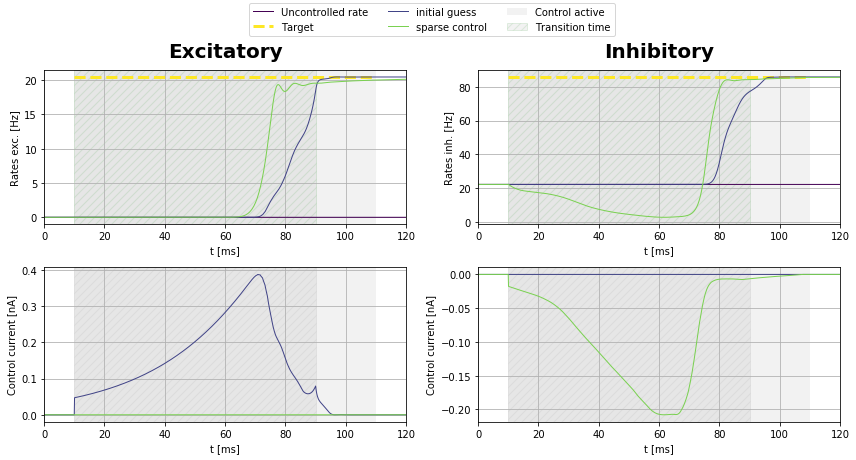

In [298]:
for i in inh_: 
    file_ = "init_0_" + str(i)
    aln.params.ext_exc_current = ext_exc[i]
    aln.params.ext_inh_current = ext_inh[i]
    
    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],
        [costnode_init[i], costnode_0[i]], [[1.,0.,1.], [1.,0.,1.]], dur,
        dur_pre, dur_post, initVars[i], target[i], path, filename_ = file_, transition_time_ = trans_time,
        labels_ = ["initial guess", "sparse control"], print_cost_=False)